# Ising model CFTP test

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import sys
import os

repo_root = os.path.abspath('..')

if repo_root not in sys.path:
    sys.path.append(repo_root)

%load_ext autoreload
%autoreload 2

from src.ising import Ising
from src.lattice import torus
from src.perfectSim import cftp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate lattice, 3x3 torus

In [13]:
lattice = torus(3)
print(f'The torus has {lattice.n_sites} sites')
print(f'Neighbour sets: {lattice.nbr}')

The torus has 9 sites
Neighbour sets: [[6 3 2 1]
 [7 4 0 2]
 [8 5 1 0]
 [0 6 5 4]
 [1 7 3 5]
 [2 8 4 3]
 [3 0 8 7]
 [4 1 6 8]
 [5 2 7 6]]


## Total magnetisation

The total magnetisation of a state is the sum of all it's spins. We represent a single state with an array of length |V|, each element represents one site and has a spin of -1 or +1. So, for the 3x3 torus there are 9 possible total magnetisations, $\set{-9, 7, \dots, 7, 9}$.

In [14]:
# Instantiate the Ising model
ising = Ising(lattice=lattice, beta=0.2, h=0.0)

print(f'The highest state under the partial order is {ising.top} with a total magnetisation of {ising.top.sum()}')
print(f'The lowest state under the partial order is {ising.bottom} with a total magnetisation of {ising.bottom.sum()}')

The highest state under the partial order is [1 1 1 1 1 1 1 1 1] with a total magnetisation of 9
The lowest state under the partial order is [-1 -1 -1 -1 -1 -1 -1 -1 -1] with a total magnetisation of -9


## The CFTP

The CFTP allows us to sample from the stationary distribution of a chain.

In [15]:
sample = cftp(ising)
print(sample)

[[-1 -1 -1 -1 -1 -1 -1 -1 -1]]


To assess the correctness of the algorithm we will drawn 1000 samples and plot the distribution of total magnetism and compare against the known stationary distribution.

In [16]:
samples_1000 = cftp(ising, B=100000)
print(samples_1000[:5])

[[ 1  1 -1 -1 -1 -1 -1 -1 -1]
 [ 1  1  1  1  1  1  1  1  1]
 [ 1  1  1 -1  1 -1  1  1 -1]
 [ 1  1 -1  1  1  1 -1  1 -1]
 [-1 -1 -1 -1 -1  1  1  1 -1]]


In [17]:
magnetizations = samples_1000.sum(axis=1)
print(magnetizations[:5])

[-5  9  3  3 -3]


In [18]:
import itertools

# Theretical magnetisation dist

def theoretical_magnetization_dist(lattice, beta: float, h: float = 0.0):
    n = lattice.n_sites
    all_states = np.array(list(itertools.product([-1, 1], repeat=n)))

    interactions = (all_states * all_states[:, lattice.nbr].sum(axis=2)).sum(axis=1) / 2.0

    mags = all_states.sum(axis=1)

    energies = -interactions - (h * mags)
    weights = np.exp(-beta * energies)

    Z = np.sum(weights)
    probs = weights / Z

    exact_probs = {}
    for m in np.unique(mags):
        exact_probs[int(m)] = np.sum(probs[mags == m])
    
    return exact_probs

In [27]:
theoretical_mag_probs = theoretical_magnetization_dist(lattice, 0.2, 0.0)
print(theoretical_mag_probs)

{-9: np.float64(0.04643301213420021), -7: np.float64(0.08437197122908746), -5: np.float64(0.10989035528078381), -3: np.float64(0.12632047763236992), -1: np.float64(0.13298418372355864), 1: np.float64(0.13298418372355864), 3: np.float64(0.12632047763236992), 5: np.float64(0.10989035528078381), 7: np.float64(0.08437197122908746), 9: np.float64(0.04643301213420021)}


In [20]:
empirical_mag_probs = {}
for m in range(-9, 10, 2):
    empirical_mag_probs[m] = np.sum(magnetizations == m) / len(magnetizations)

print(empirical_mag_probs)

{-9: np.float64(0.04723), -7: np.float64(0.08365), -5: np.float64(0.11036), -3: np.float64(0.1268), -1: np.float64(0.13245), 1: np.float64(0.13134), 3: np.float64(0.1262), 5: np.float64(0.11114), 7: np.float64(0.0835), 9: np.float64(0.04733)}


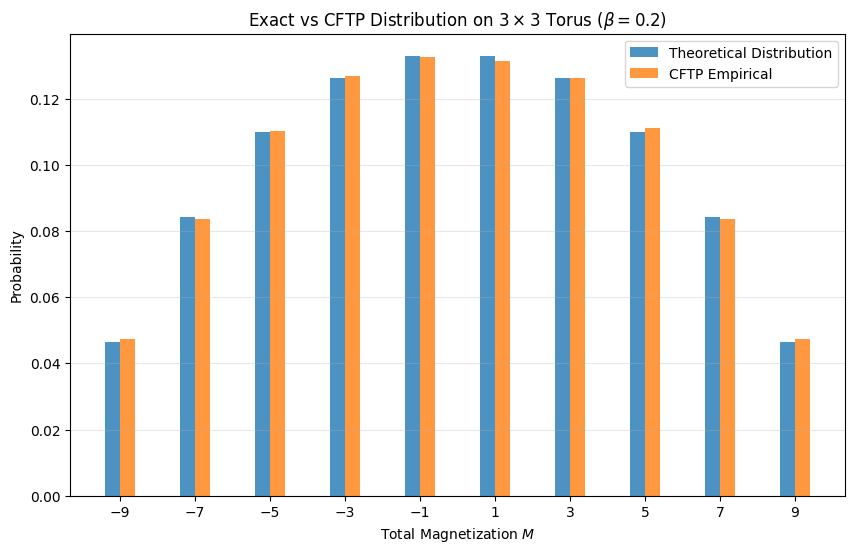

In [ ]:
mags = np.array(list(empirical_mag_probs.keys()))

theoretical_probs = np.array([theoretical_mag_probs.get(m, 0.0) for m in mags])
empirical_probs = np.array([empirical_mag_probs[m] for m in mags])

plt.figure(figsize=(10, 6))
width = 0.4

plt.bar(mags - width/2, theoretical_probs, width=width, label='Theoretical Distribution', alpha=0.8)
plt.bar(mags + width/2, empirical_probs, width=width, label='CFTP Empirical', alpha=0.8)

plt.xlabel('Total Magnetization $M$')
plt.ylabel('Probability')
plt.title('Exact vs CFTP Distribution on $3 \\times 3$ Torus ($\\beta = 0.2$)')
plt.xticks(mags)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [30]:
from scipy.stats import chisquare


N = len(magnetizations)
print(f"Total samples (N): {N}")

unique_vals, counts = np.unique(magnetizations, return_counts=True)
empirical_counts_dict = dict(zip(unique_vals, counts))

states = sorted(theoretical_mag_probs.keys())

f_obs = []
f_exp = []

for state in states:
    obs = empirical_counts_dict.get(state, 0)
    exp = theoretical_mag_probs[state] * N
    
    f_obs.append(obs)
    f_exp.append(exp)

f_obs = np.array(f_obs)
f_exp = np.array(f_exp)

print("\nState | Observed Count | Expected Count")
print("-" * 39)
for s, obs, exp in zip(states, f_obs, f_exp):
    print(f"{s:5} | {obs:14} | {exp:14.1f}")

stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)

print(f"\nChi-squared Statistic: {stat:.2f}")
print(f"P-value: {p_value:.6e}")

if p_value < 0.05:
    print("\nResult: Reject the null hypothesis.")
    print("The distributions are statistically different at the 5% level.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("The empirical distribution statistically matches the theoretical distribution.")

Total samples (N): 100000

State | Observed Count | Expected Count
---------------------------------------
   -9 |           4723 |         4643.3
   -7 |           8365 |         8437.2
   -5 |          11036 |        10989.0
   -3 |          12680 |        12632.0
   -1 |          13245 |        13298.4
    1 |          13134 |        13298.4
    3 |          12620 |        12632.0
    5 |          11114 |        10989.0
    7 |           8350 |         8437.2
    9 |           4733 |         4643.3

Chi-squared Statistic: 8.68
P-value: 4.670904e-01

Result: Fail to reject the null hypothesis.
The empirical distribution statistically matches the theoretical distribution.
